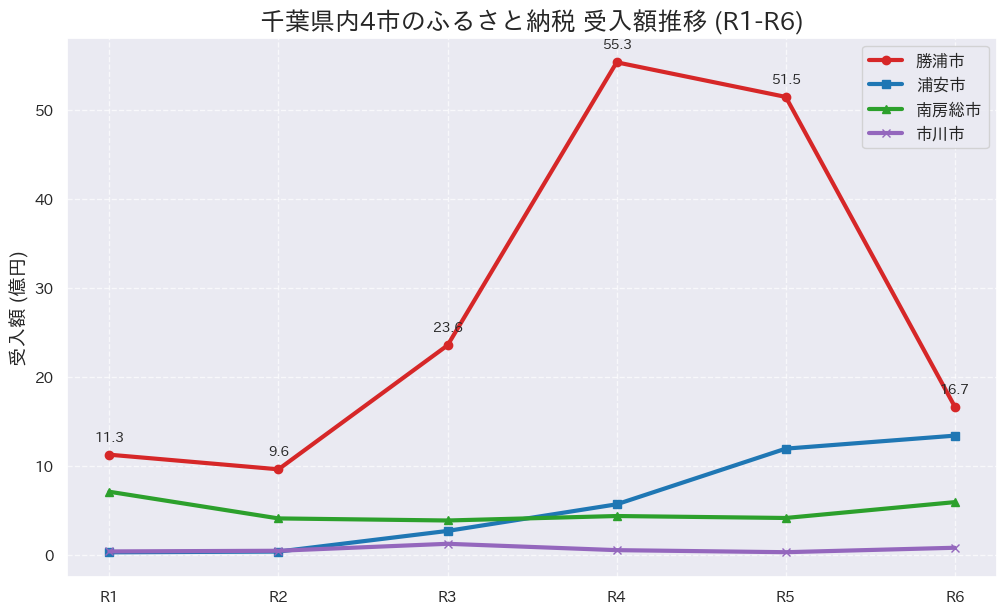

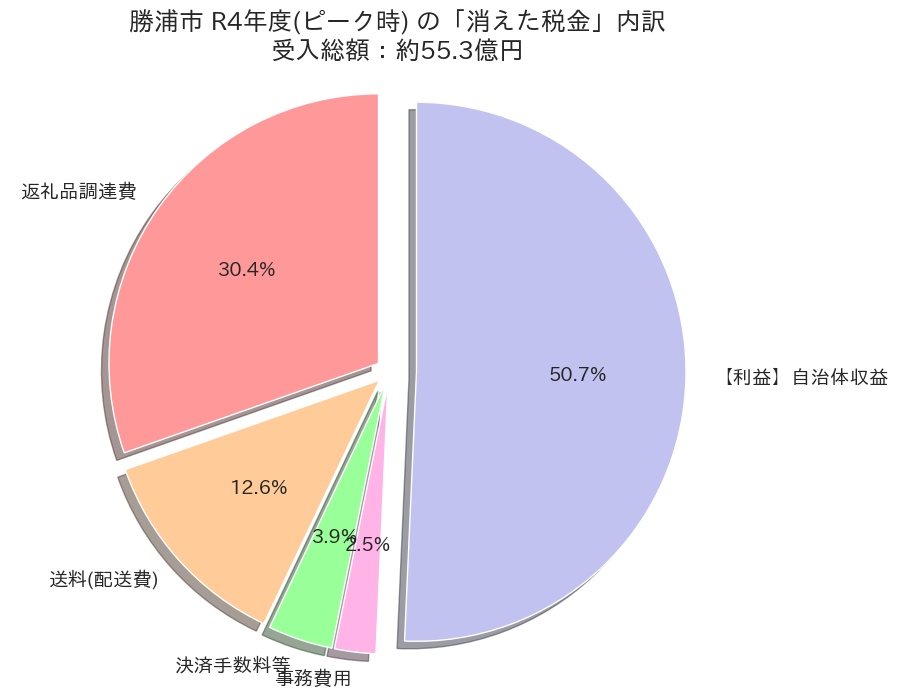

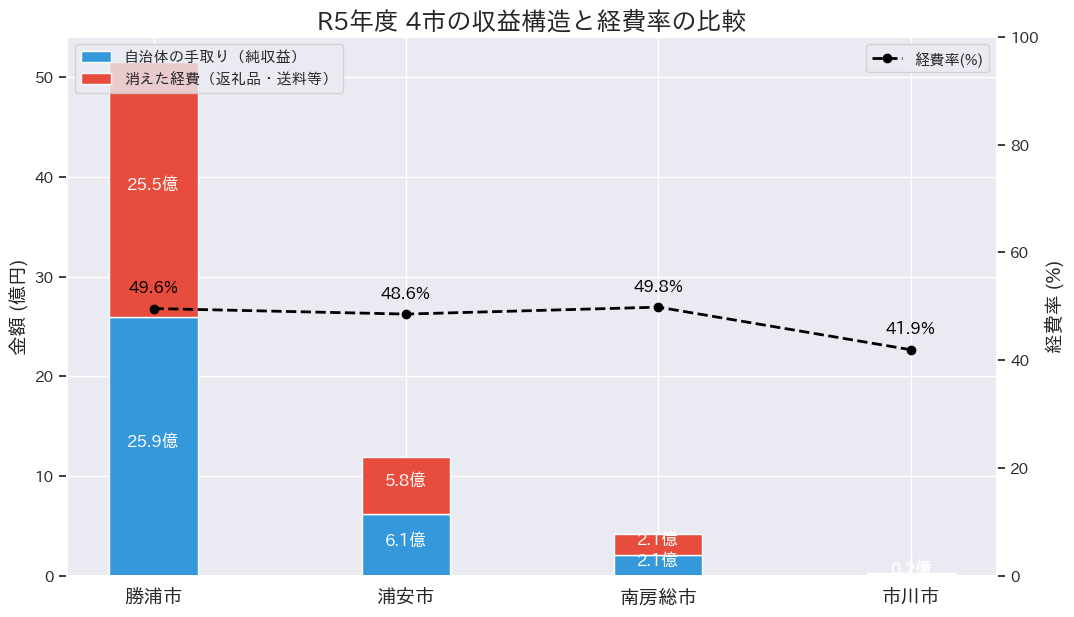

In [4]:
# ==========================================
# 1. 日本語フォントのインストール（必須）
# ==========================================
!pip install japanize-matplotlib
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
import seaborn as sns
import numpy as np

# グラフのスタイル設定
sns.set(font="IPAexGothic") # 日本語フォント適用
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# ==========================================
# 2. データの定義（OCRデータより転記）
# ==========================================
# 単位：円

data = {
    "年度": ["R1", "R2", "R3", "R4", "R5", "R6"],
    # 勝浦市
    "勝浦_受入額": [1127204121, 963121879, 2356052000, 5534178000, 5145389300, 1665885900],
    "勝浦_経費":   [512198777,  524436821, 1274115990, 2764237984, 2551597239, 824090499],
    # 浦安市
    "浦安_受入額": [30941050,   39265000,  271136940,  569979000,  1195235353, 1341196798],
    "浦安_経費":   [9481496,    16481093,  119456263,  264284005,  580385541,  663030859],
    # 市川市
    "市川_受入額": [40864553,   48128302,  126516910,  55152657,   32067530,   82088616],
    "市川_経費":   [4638192,    5003249,   10559266,   8946042,    13450382,   27432324],
    # 南房総市
    "南房総_受入額": [711079795, 411461841, 388218371, 438459679, 416443700, 594520000],
    "南房総_経費":   [300760290, 11638200,  183531758, 219179875, 207571393, 292509500]
}

df = pd.DataFrame(data)

# 単位を「億円」に変換
cols = [c for c in df.columns if "受入額" in c or "経費" in c]
for c in cols:
    df[c + "_億円"] = df[c] / 100000000

# ==========================================
# 3. グラフ描画
# ==========================================

# --- グラフ1: 受入額の時系列推移 ---
plt.figure(figsize=(12, 7))
plt.plot(df["年度"], df["勝浦_受入額_億円"], marker='o', linewidth=3, label='勝浦市', color='#d62728')
plt.plot(df["年度"], df["浦安_受入額_億円"], marker='s', linewidth=3, label='浦安市', color='#1f77b4')
plt.plot(df["年度"], df["南房総_受入額_億円"], marker='^', linewidth=3, label='南房総市', color='#2ca02c')
plt.plot(df["年度"], df["市川_受入額_億円"], marker='x', linewidth=3, label='市川市', color='#9467bd')

plt.title("千葉県内4市のふるさと納税 受入額推移 (R1-R6)", fontsize=18, fontweight='bold')
plt.ylabel("受入額 (億円)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# 値のラベルを表示
for i, txt in enumerate(df["勝浦_受入額_億円"]):
    plt.annotate(f"{txt:.1f}", (df["年度"][i], df["勝浦_受入額_億円"][i]), xytext=(0,10), textcoords='offset points', ha='center', fontsize=10)

plt.show()


# --- グラフ2: 勝浦市 R4(ピーク時)の経費構造 ---
# R4データの抽出（OCR画像より補足：内訳概算）
# 受入額: 55.3億円, 経費合計: 27.6億円
# 経費内訳: 調達費(返礼品代) 16.6億, 送料 6.8億, 広報 0.0億?, 事務 1.3億, 決済手数料 1.6億
# ※OCRのR4勝浦シートの値を参照
katsuura_r4_income = 55.34
katsuura_r4_breakdown = {
    "返礼品調達費": 16.60,
    "送料(配送費)": 6.86,
    "決済手数料等": 1.60 + 0.52, # 決済+広報などその他
    "事務費用": 1.35,
    "【利益】自治体収益": 55.34 - 27.64
}

labels = katsuura_r4_breakdown.keys()
sizes = katsuura_r4_breakdown.values()
colors = ['#ff9999', '#ffcc99', '#99ff99', '#ffb3e6', '#c2c2f0']
explode = (0.05, 0.05, 0.05, 0.05, 0.1)  # 利益を目立たせる

plt.figure(figsize=(10, 8))
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90, colors=colors, textprops={'fontsize': 14})
plt.title("勝浦市 R4年度(ピーク時) の「消えた税金」内訳\n受入総額：約55.3億円", fontsize=18, fontweight='bold')
plt.axis('equal')
plt.show()


# --- グラフ3: R5年度 4市の実質手取りと経費率比較 ---
cities = ['勝浦市', '浦安市', '南房総市', '市川市']
income_r5 = [df.loc[4, "勝浦_受入額_億円"], df.loc[4, "浦安_受入額_億円"], df.loc[4, "南房総_受入額_億円"], df.loc[4, "市川_受入額_億円"]]
expense_r5 = [df.loc[4, "勝浦_経費_億円"], df.loc[4, "浦安_経費_億円"], df.loc[4, "南房総_経費_億円"], df.loc[4, "市川_経費_億円"]]
net_r5 = [i - e for i, e in zip(income_r5, expense_r5)]
ratios = [e/i*100 for i, e in zip(income_r5, expense_r5)]

x = np.arange(len(cities))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 7))

# 積み上げ棒グラフ（経費＋手取り）
p1 = ax1.bar(x, net_r5, width, label='自治体の手取り（純収益）', color='#3498db')
p2 = ax1.bar(x, expense_r5, width, bottom=net_r5, label='消えた経費（返礼品・送料等）', color='#e74c3c')

# 折れ線グラフ（経費率）
ax2 = ax1.twinx()
ax2.plot(x, ratios, color='black', marker='o', linewidth=2, linestyle='--', label='経費率(%)')
ax2.set_ylim(0, 100)
ax2.set_ylabel('経費率 (%)', fontsize=14)

ax1.set_ylabel('金額 (億円)', fontsize=14)
ax1.set_title('R5年度 4市の収益構造と経費率の比較', fontsize=18, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(cities, fontsize=14)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 値の表示
for i in range(len(cities)):
    ax1.text(x[i], net_r5[i]/2, f"{net_r5[i]:.1f}億", ha='center', color='white', fontweight='bold')
    ax1.text(x[i], net_r5[i] + expense_r5[i]/2, f"{expense_r5[i]:.1f}億", ha='center', color='white', fontweight='bold')
    ax2.text(x[i], ratios[i]+3, f"{ratios[i]:.1f}%", ha='center', color='black', fontweight='bold')

plt.grid(False)
plt.show()

### 全てのグラフを画像ファイルとして保存します

In [3]:
# --- グラフ1: 受入額の時系列推移を保存 ---
plt.figure(figsize=(12, 7))
plt.plot(df["年度"], df["勝浦_受入額_億円"], marker='o', linewidth=3, label='勝浦市', color='#d62728')
plt.plot(df["年度"], df["浦安_受入額_億円"], marker='s', linewidth=3, label='浦安市', color='#1f77b4')
plt.plot(df["年度"], df["南房総_受入額_億円"], marker='^', linewidth=3, label='南房総市', color='#2ca02c')
plt.plot(df["年度"], df["市川_受入額_億円"], marker='x', linewidth=3, label='市川市', color='#9467bd')

plt.title("千葉県内4市のふるさと納税 受入額推移 (R1-R6)", fontsize=18, fontweight='bold')
plt.ylabel("受入額 (億円)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# 値のラベルを表示
for i, txt in enumerate(df["勝浦_受入額_億円"]):
    plt.annotate(f"{txt:.1f}", (df["年度"][i], df["勝浦_受入額_億円"][i]), xytext=(0,10), textcoords='offset points', ha='center', fontsize=10)

plt.savefig('ふるさと納税_受入額推移.png')
plt.close() # メモリ解放のため閉じる


# --- グラフ2: 勝浦市 R4(ピーク時)の経費構造を保存 ---
katsuura_r4_breakdown = {
    "返礼品調達費": 16.60,
    "送料(配送費)": 6.86,
    "決済手数料等": 1.60 + 0.52,
    "事務費用": 1.35,
    "【利益】自治体収益": 55.34 - 27.64
}

labels = katsuura_r4_breakdown.keys()
sizes = katsuura_r4_breakdown.values()
colors = ['#ff9999', '#ffcc99', '#99ff99', '#ffb3e6', '#c2c2f0']
explode = (0.05, 0.05, 0.05, 0.05, 0.1)

plt.figure(figsize=(10, 8))
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90, colors=colors, textprops={'fontsize': 14})
plt.title("勝浦市 R4年度(ピーク時) の「消えた税金」内訳\n受入総額：約55.3億円", fontsize=18, fontweight='bold')
plt.axis('equal')
plt.savefig('勝浦市R4年度_経費内訳.png')
plt.close() # メモリ解放のため閉じる


# --- グラフ3: R5年度 4市の実質手取りと経費率比較を保存 ---
cities = ['勝浦市', '浦安市', '南房総市', '市川市']
income_r5 = [df.loc[4, "勝浦_受入額_億円"], df.loc[4, "浦安_受入額_億円"], df.loc[4, "南房総_受入額_億円"], df.loc[4, "市川_受入額_億円"]]
expense_r5 = [df.loc[4, "勝浦_経費_億円"], df.loc[4, "浦安_経費_億円"], df.loc[4, "南房総_経費_億円"], df.loc[4, "市川_経費_億円"]]
net_r5 = [i - e for i, e in zip(income_r5, expense_r5)]
ratios = [e/i*100 for i, e in zip(income_r5, expense_r5)]

x = np.arange(len(cities))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 7))

# 積み上げ棒グラフ（経費＋手取り）
p1 = ax1.bar(x, net_r5, width, label='自治体の手取り（純収益）', color='#3498db')
p2 = ax1.bar(x, expense_r5, width, bottom=net_r5, label='消えた経費（返礼品・送料等）', color='#e74c3c')

# 折れ線グラフ（経費率）
ax2 = ax1.twinx()
ax2.plot(x, ratios, color='black', marker='o', linewidth=2, linestyle='--', label='経費率(%)')
ax2.set_ylim(0, 100)
ax2.set_ylabel('経費率 (%)', fontsize=14)

ax1.set_ylabel('金額 (億円)', fontsize=14)
ax1.set_title('R5年度 4市の収益構造と経費率の比較', fontsize=18, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(cities, fontsize=14)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# 値の表示
for i in range(len(cities)):
    ax1.text(x[i], net_r5[i]/2, f"{net_r5[i]:.1f}億", ha='center', color='white', fontweight='bold')
    ax1.text(x[i], net_r5[i] + expense_r5[i]/2, f"{expense_r5[i]:.1f}億", ha='center', color='white', fontweight='bold')
    ax2.text(x[i], ratios[i]+3, f"{ratios[i]:.1f}%", ha='center', color='black', fontweight='bold')

plt.grid(False)
plt.savefig('R5年度_4市収益構造と経費率比較.png')
plt.close() # メモリ解放のため閉じる

print("全てのグラフがPNGファイルとしてカレントディレクトリに保存されました。")


全てのグラフがPNGファイルとしてカレントディレクトリに保存されました。
